In [1]:
from src.data_loader import load_data
from src.preprocess import prepare_data, print_vectorized_sample
from src.ML.train_NN import train_model, print_NN_input_sample, TextClassifier, DeepTextClassifier

#from src.analysis import  intra_category_similarity
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
#from src.ML.train_svm import train_SVM
#from src.ML.train_rf import train_random_forest

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (3,2)


DATA_PATH = "/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv"

In [2]:
print("--- 1. Loading and Preparing Data ---")
df = load_data(DATA_PATH)

--- 1. Loading and Preparing Data ---
Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...


Simple Feed Forward NN
Class weights: tensor([0.6869, 1.8377], device='cuda:0')
Test accuracy: 0.7266
              precision    recall  f1-score   support

           0     0.7944    0.8416    0.8173       101
           1     0.5000    0.4211    0.4571        38

    accuracy                         0.7266       139
   macro avg     0.6472    0.6313    0.6372       139
weighted avg     0.7139    0.7266    0.7188       139

Test accuracy: 0.7266


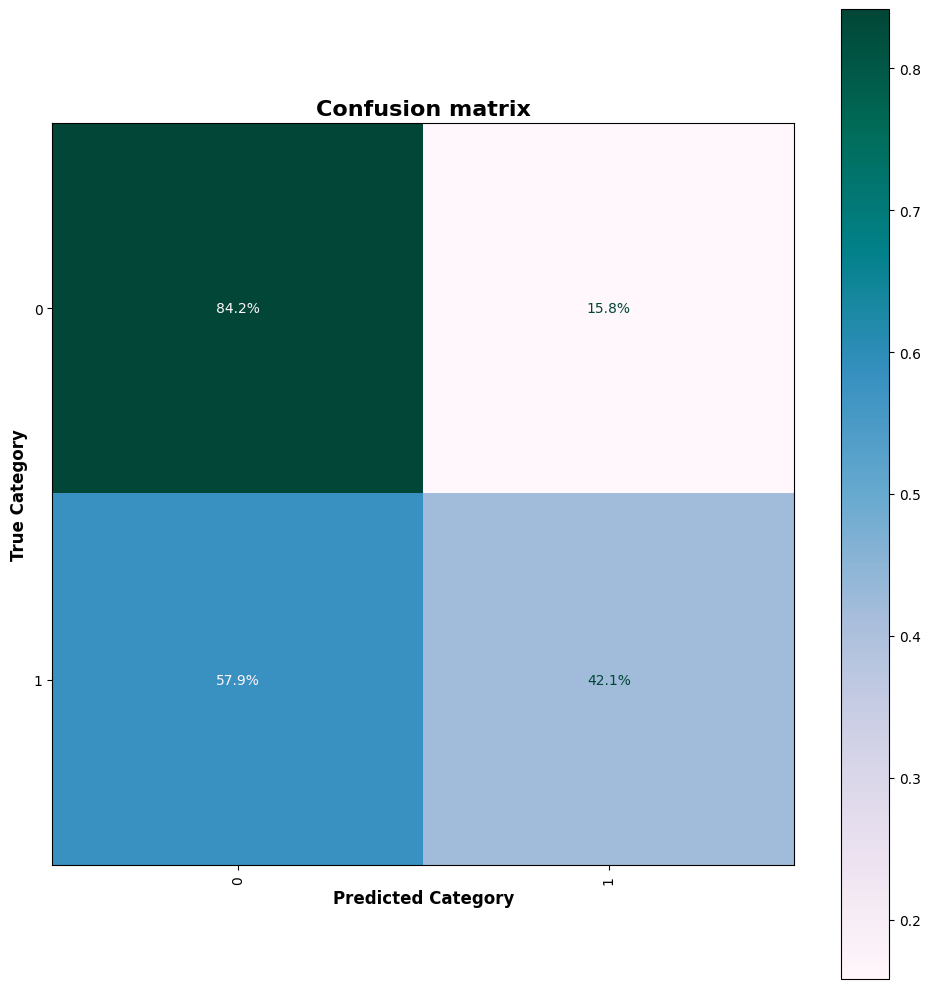

<Figure size 300x200 with 0 Axes>

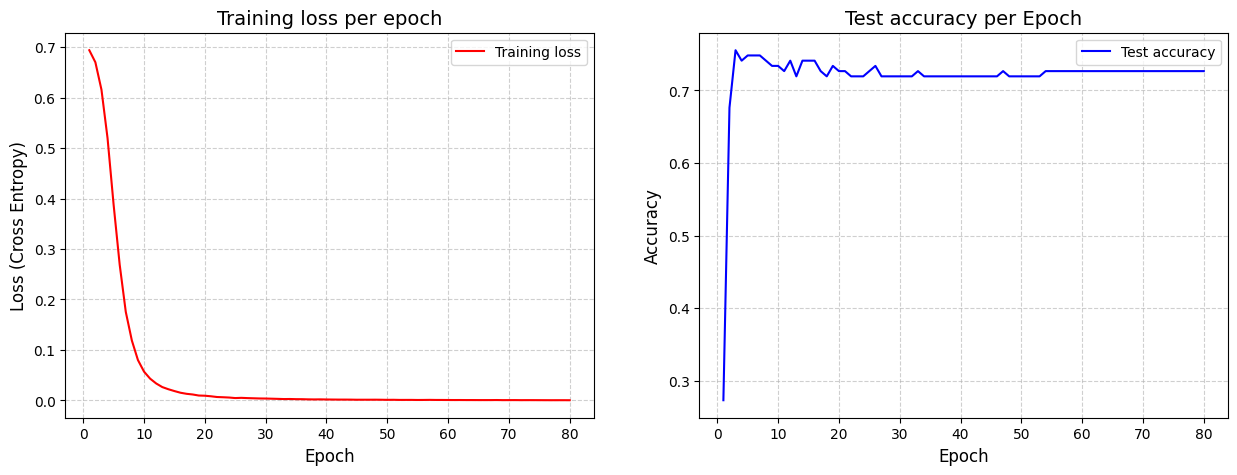

<Figure size 300x200 with 0 Axes>

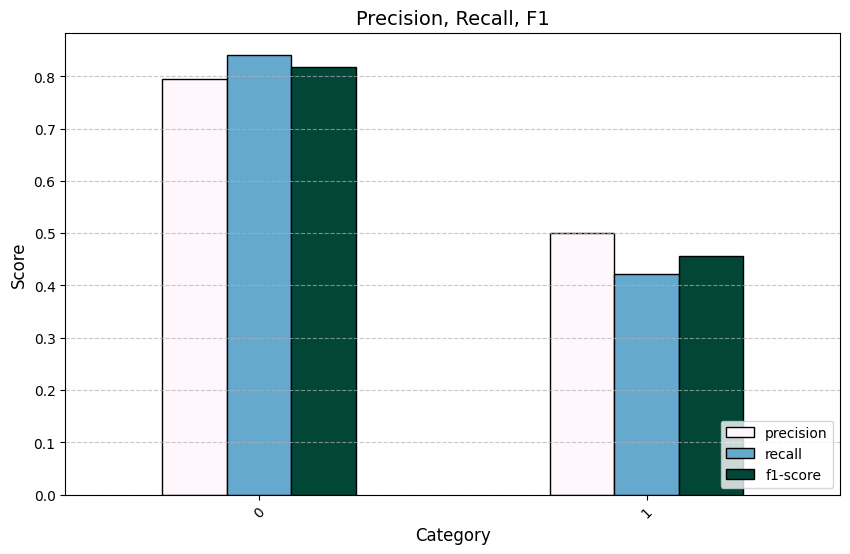

<Figure size 300x200 with 0 Axes>

In [6]:
from src.ML.train_NN import TextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Simple Feed Forward NN")

simple_model, class_to_idx, simple_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 128},
    epochs=80,
    lr=0.001
)


Deep Feed Forward NN
Class weights: tensor([0.6869, 1.8377], device='cuda:0')
Test accuracy: 0.6906
              precision    recall  f1-score   support

           0     0.8295    0.7228    0.7725       101
           1     0.4510    0.6053    0.5169        38

    accuracy                         0.6906       139
   macro avg     0.6403    0.6640    0.6447       139
weighted avg     0.7261    0.6906    0.7026       139

Test accuracy: 0.6906


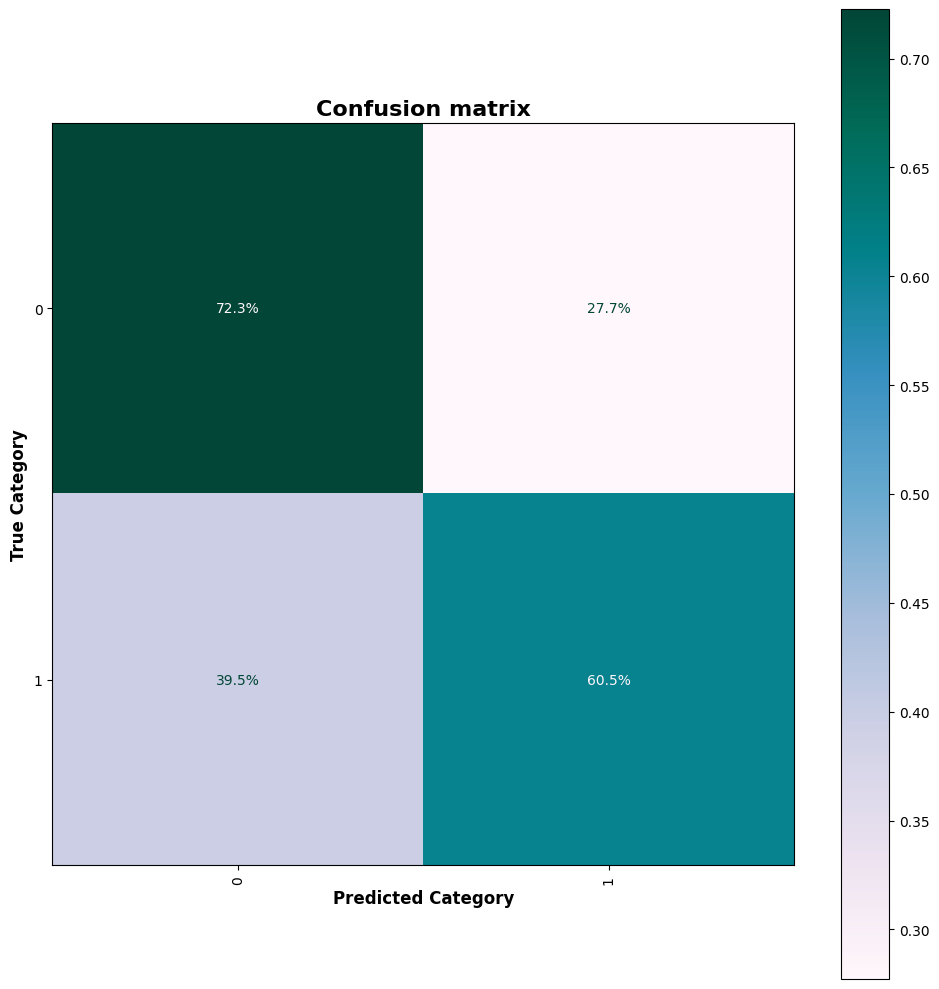

<Figure size 300x200 with 0 Axes>

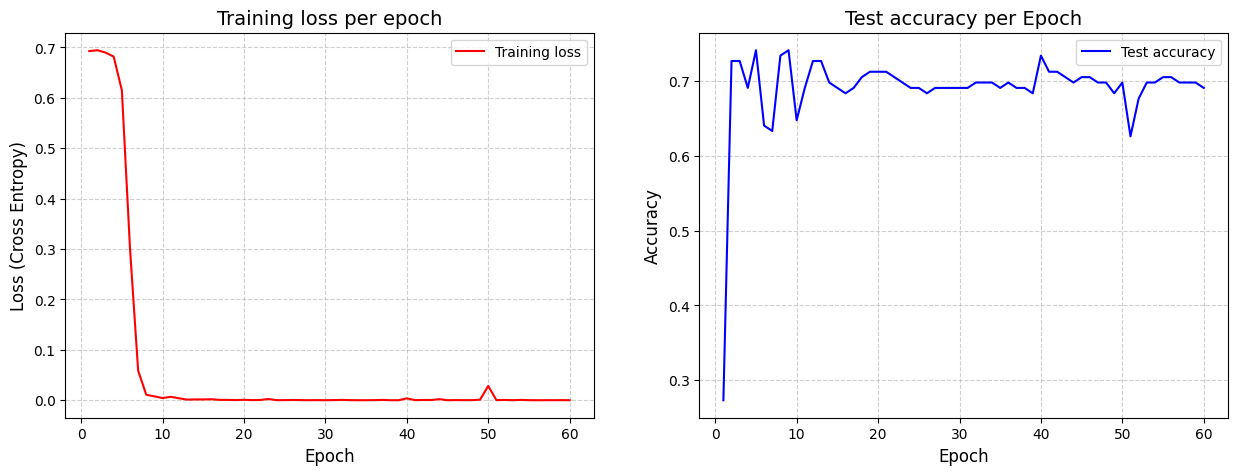

<Figure size 300x200 with 0 Axes>

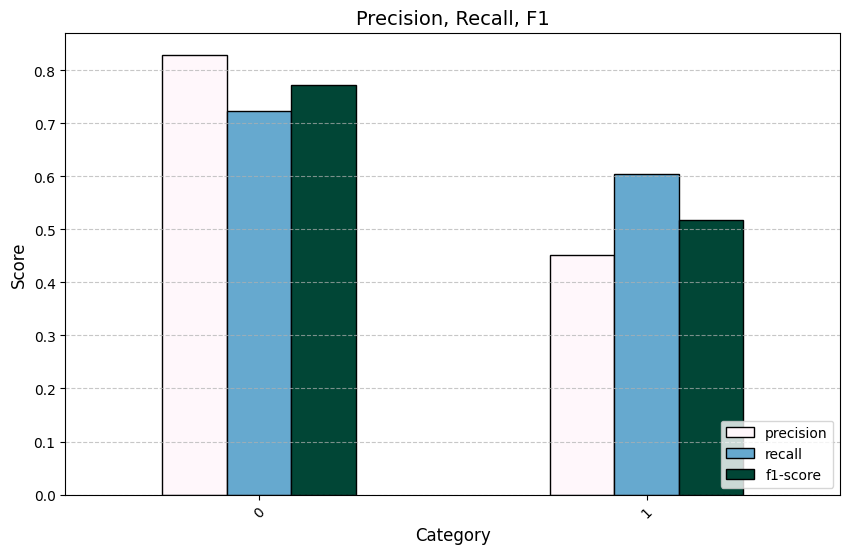

<Figure size 300x200 with 0 Axes>

In [ ]:
from src.ML.train_NN import DeepTextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Deep Feed Forward NN")

deep_model, class_to_idx, deep_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [256, 128, 64]},
    epochs=60,
    lr=0.001
)
